<a href="https://colab.research.google.com/github/marcehluna/DVxC-VxCI-TP3/blob/main/DVxC-VxCI-TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires - Visión por Computadora I - TP3 - 3° bimestre 2026

### Grupo: Facundo Silberstein - Ian Sztenberg - Marcelo Luna

### 1. Objetivo

El objetivo de este trabajo es implementar algoritmos de template matching que permitan encontrar el logotipo de la gaseosa en las imágenes provistas, a partir de un template de referencia. Los resultados deben visualizarse con bounding boxes e incluyendo el nivel de confianza de cada detección.

Condiciones a satisfacer

1. Obtener una detección del logo en cada imagen, sin falsos positivos.
2. Plantear y validar un algoritmo para múltiples detecciones en la imagen 'coca_multi.png' usando el mismo template.
3. Generalizar el algoritmo del punto anterior para que funcione en todas las imágenes.


### 2. Setup

Se importan las librerías necesarias para ejecutar el notebook.


In [18]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


### 3. Carga de las imágenes

Se resuelve la carpeta base del TP y se carga el material en tres grupos: el **template**, la imagen **coca_multi** (ítem 2) y el resto de **escenas**. Si no se encuentran las rutas por defecto, se pide al usuario que indique la ruta base.


In [19]:
MULTI_FILENAME = "coca_multi.png"


def material_disponible(base_dir: Path) -> bool:
    """Verifica que existan template e images en la ruta base."""
    template_ok = (base_dir / "template" / "pattern.png").is_file()
    images_ok = (base_dir / "images").is_dir()
    return template_ok and images_ok


def resolver_ruta_base() -> Path:
    """Usa el directorio actual; si falta el material, pide la ruta al usuario."""
    base_dir = Path(".")
    if material_disponible(base_dir):
        return base_dir.resolve()

    print("No se encontró el material en las rutas por defecto (./template y ./images).")
    while True:
        ingresada = input("Indicá la ruta base del TP (carpeta que contiene 'template' e 'images'): ").strip()
        candidata = Path(ingresada).expanduser()
        if material_disponible(candidata):
            return candidata.resolve()
        print(f"Material incompleto en '{candidata}'. Revisá la ruta e intentá de nuevo.")


def cargar_imagen(ruta: Path):
    """Lee una imagen en BGR; lanza error si falla la lectura."""
    imagen = cv2.imread(str(ruta))
    if imagen is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")
    return imagen


def cargar_material(base_dir: Path):
    """
    Carga template, coca_multi y el resto de escenas.

    Retorna:
        template: imagen del patrón
        coca_multi: imagen para múltiples detecciones
        imagenes: dict {nombre_archivo: imagen} sin coca_multi
    """
    ruta_template = base_dir / "template" / "pattern.png"
    carpeta_images = base_dir / "images"
    ruta_multi = carpeta_images / MULTI_FILENAME

    if not ruta_multi.is_file():
        raise FileNotFoundError(f"No se encontró {MULTI_FILENAME} en {carpeta_images}")

    template = cargar_imagen(ruta_template)
    coca_multi = cargar_imagen(ruta_multi)

    # Escenas: todo lo de images/ excepto coca_multi
    imagenes = {}
    for ruta in sorted(carpeta_images.iterdir()):
        if not ruta.is_file():
            continue
        if ruta.name == MULTI_FILENAME:
            continue
        imagenes[ruta.name] = cargar_imagen(ruta)

    if not imagenes:
        raise FileNotFoundError(f"No se encontraron escenas en {carpeta_images}")

    return template, coca_multi, imagenes


BASE_DIR = resolver_ruta_base()
template, coca_multi, imagenes = cargar_material(BASE_DIR)

print(f"Ruta base: {BASE_DIR}")
print(f"Template: {template.shape}")
print(f"coca_multi: {coca_multi.shape}")
print(f"Escenas ({len(imagenes)}):")
for nombre, img in imagenes.items():
    print(f"  - {nombre}: {img.shape}")


Ruta base: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/03. Visión por Computadora 1/TP3/DVxC-VxCI-TP3
Template: (175, 400, 3)
coca_multi: (598, 799, 3)
Escenas (6):
  - COCA-COLA-LOGO.jpg: (1389, 1389, 3)
  - coca_logo_1.png: (500, 207, 3)
  - coca_logo_2.png: (363, 233, 3)
  - coca_retro_1.png: (493, 715, 3)
  - coca_retro_2.png: (429, 715, 3)
  - logo_1.png: (450, 687, 3)


### 4. Resolución punto 1

#### 4.1 Template matching multi-escala

Se eligió **template matching multi-escala** con la métrica `TM_CCOEFF_NORMED` porque da una confianza interpretable entre 0 y 1, y con un umbral estricto ayuda a evitar falsos positivos. Como el matching solo es invariante a desplazamiento, se busca el template en varias escalas (pirámides / redimensionado). Se trabajó en escala de grises para unificar fotos color y avisos monocromos, y también se probó el template invertido cuando el logo aparece con contraste al revés (p. ej. blanco sobre rojo). Por imagen se conserva el mejor pico; solo se acepta si supera el umbral de confianza.


Umbral de confianza: 0.45
imagen                           score  escala   inv estado
-----------------------------------------------------------------
COCA-COLA-LOGO.jpg               0.612   3.197  True aceptada
coca_logo_1.png                  0.379   0.168  True rechazada (posible FP / score bajo)
coca_logo_2.png                  0.447   0.159  True rechazada (posible FP / score bajo)
coca_retro_1.png                 0.630   1.291 False aceptada
coca_retro_2.png                 0.671   0.377  True aceptada
logo_1.png                       0.515   0.143  True aceptada


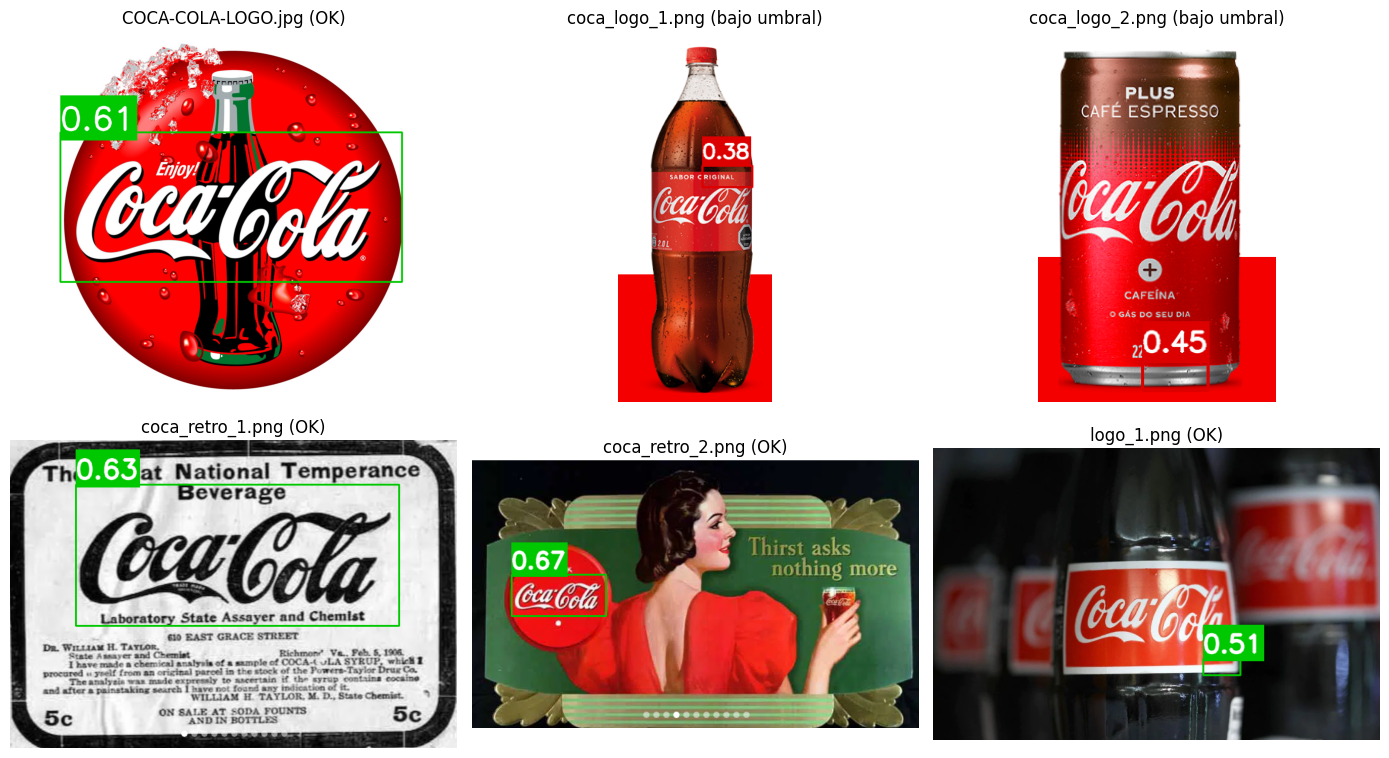

In [20]:
# Parámetros del ítem 1
METRICA_TM = cv2.TM_CCOEFF_NORMED
UMBRAL_CONFIANZA = 0.45
N_ESCALAS = 40
MIN_LADO_TEMPLATE = 25  # evita plantillas demasiado chicas / ruidosas


def escalas_validas(alto_img, ancho_img, alto_tmpl, ancho_tmpl, n_escalas, min_lado):
    """Escalas en las que el template redimensionado entra en la imagen."""
    escala_max = min((ancho_img - 1) / ancho_tmpl, (alto_img - 1) / alto_tmpl)
    escala_min = max(min_lado / ancho_tmpl, min_lado / alto_tmpl)
    if escala_max <= escala_min:
        return np.array([max(0.05, escala_max * 0.98)])
    return np.geomspace(escala_min, escala_max, n_escalas)


def detectar_logo_multiescala(
    imagen_bgr,
    template_bgr,
    metrica=METRICA_TM,
    n_escalas=N_ESCALAS,
    min_lado=MIN_LADO_TEMPLATE,
    probar_invertido=True,
):
    """
    Template matching multi-escala en escala de grises.

    Retorna un dict con score, bbox (x, y, w, h), escala y si se usó template invertido.
    """
    imagen_gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
    template_gris = cv2.cvtColor(template_bgr, cv2.COLOR_BGR2GRAY)
    alto_t, ancho_t = template_gris.shape[:2]

    mejor = None
    for escala in escalas_validas(
        *imagen_gris.shape[:2], alto_t, ancho_t, n_escalas, min_lado
    ):
        ancho = int(round(ancho_t * escala))
        alto = int(round(alto_t * escala))
        if ancho < 15 or alto < 10:
            continue
        if ancho >= imagen_gris.shape[1] or alto >= imagen_gris.shape[0]:
            continue

        interpolacion = cv2.INTER_AREA if escala < 1 else cv2.INTER_CUBIC
        tmpl = cv2.resize(template_gris, (ancho, alto), interpolation=interpolacion)

        variantes = [(False, tmpl)]
        if probar_invertido:
            variantes.append((True, 255 - tmpl))

        for invertido, tmpl_var in variantes:
            mapa = cv2.matchTemplate(imagen_gris, tmpl_var, metrica)
            _, max_val, _, max_loc = cv2.minMaxLoc(mapa)
            candidato = {
                "score": float(max_val),
                "x": int(max_loc[0]),
                "y": int(max_loc[1]),
                "w": ancho,
                "h": alto,
                "escala": float(escala),
                "invertido": invertido,
            }
            if mejor is None or candidato["score"] > mejor["score"]:
                mejor = candidato

    return mejor


def dibujar_deteccion(imagen_bgr, deteccion, umbral, titulo):
    """Copia la imagen y dibuja BB + confianza con tipografía legible."""
    vis = imagen_bgr.copy()
    aceptada = deteccion is not None and deteccion["score"] >= umbral

    if deteccion is not None:
        x, y, w, h = deteccion["x"], deteccion["y"], deteccion["w"], deteccion["h"]
        color = (0, 200, 0) if aceptada else (0, 0, 220)
        # Grosor del rectángulo según tamaño de imagen
        grosor_caja = max(2, int(round(min(vis.shape[:2]) / 250)))
        cv2.rectangle(vis, (x, y), (x + w, y + h), color, grosor_caja)

        etiq = f"{deteccion['score']:.2f}"
        # Escala de fuente proporcional al tamaño de la imagen (más legible en subplot)
        escala_fuente = max(0.9, min(vis.shape[:2]) / 350)
        grosor_texto = max(2, int(round(escala_fuente * 2.2)))
        (tw, th), baseline = cv2.getTextSize(
            etiq, cv2.FONT_HERSHEY_SIMPLEX, escala_fuente, grosor_texto
        )
        # Ubicar el texto arriba del BB si hay lugar; si no, adentro
        texto_x = x
        texto_y = y - 10 if y - th - 10 >= 0 else y + th + 10
        # Fondo semiópico para contraste
        cv2.rectangle(
            vis,
            (texto_x, texto_y - th - baseline),
            (texto_x + tw, texto_y + baseline),
            color,
            -1,
        )
        cv2.putText(
            vis,
            etiq,
            (texto_x, texto_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            escala_fuente,
            (255, 255, 255),
            grosor_texto,
            cv2.LINE_AA,
        )

    return vis, aceptada


# Ítem 1: solo las escenas (sin coca_multi)
detecciones_item1 = {}
for nombre, img in imagenes.items():
    detecciones_item1[nombre] = detectar_logo_multiescala(img, template)

# Resumen tabular
print(f"Umbral de confianza: {UMBRAL_CONFIANZA}")
print(f"{'imagen':30} {'score':>7} {'escala':>7} {'inv':>5} {'estado'}")
print("-" * 65)
for nombre, det in detecciones_item1.items():
    ok = det["score"] >= UMBRAL_CONFIANZA
    estado = "aceptada" if ok else "rechazada (posible FP / score bajo)"
    print(
        f"{nombre:30} {det['score']:7.3f} {det['escala']:7.3f} "
        f"{str(det['invertido']):>5} {estado}"
    )

# Visualización
n = len(imagenes)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (nombre, img) in zip(axes, imagenes.items()):
    vis, aceptada = dibujar_deteccion(
        img, detecciones_item1[nombre], UMBRAL_CONFIANZA, nombre
    )
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    estado = "OK" if aceptada else "bajo umbral"
    ax.set_title(f"{nombre} ({estado})")
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


#### 4.2 Resultados TM multi-escala

El matching en grises funciona bien cuando el logo se parece al template y está bastante “plano”: *COCA-COLA-LOGO*, *coca_retro_1* y *coca_retro_2* quedan bien localizados.

En cambio, en botella y lata el método se degrada: hay curvatura, brillos y tipografía distinta. *coca_logo_1* queda debajo del umbral y *coca_logo_2* ni siquiera apunta al logo correcto (el umbral evita aceptar ese error).

El caso más engañoso es *logo_1*: el score supera 0.45 y la caja se ve en verde, pero marca una zona donde no está el patrón. Conclusión: un umbral ayuda, pero no alcanza solo; también debe verificarse que la caja caiga sobre el logo.


#### 4.3 Template matching sobre bordes (Canny)

Para intentar mejorar los resultados del experimento anterior, se probó el mismo esquema multi-escala pero correlacionando **bordes**: Canny reduce el peso del color/brillo y enfatiza la forma del script.

Como el mapa de Canny es muy disperso para *CCOEFF_NORMED*, se engrosaron y suavizaron los bordes (dilatación + blur) para que la correlación sea más estable.


Umbral de confianza (bordes): 0.5
imagen                           score  escala estado
------------------------------------------------------------
COCA-COLA-LOGO.jpg               0.534   0.355 aceptada
coca_logo_1.png                  0.788   0.405 aceptada
coca_logo_2.png                  0.572   0.571 aceptada
coca_retro_1.png                 0.576   0.449 aceptada
coca_retro_2.png                 0.923   0.359 aceptada
logo_1.png                       0.570   0.750 aceptada


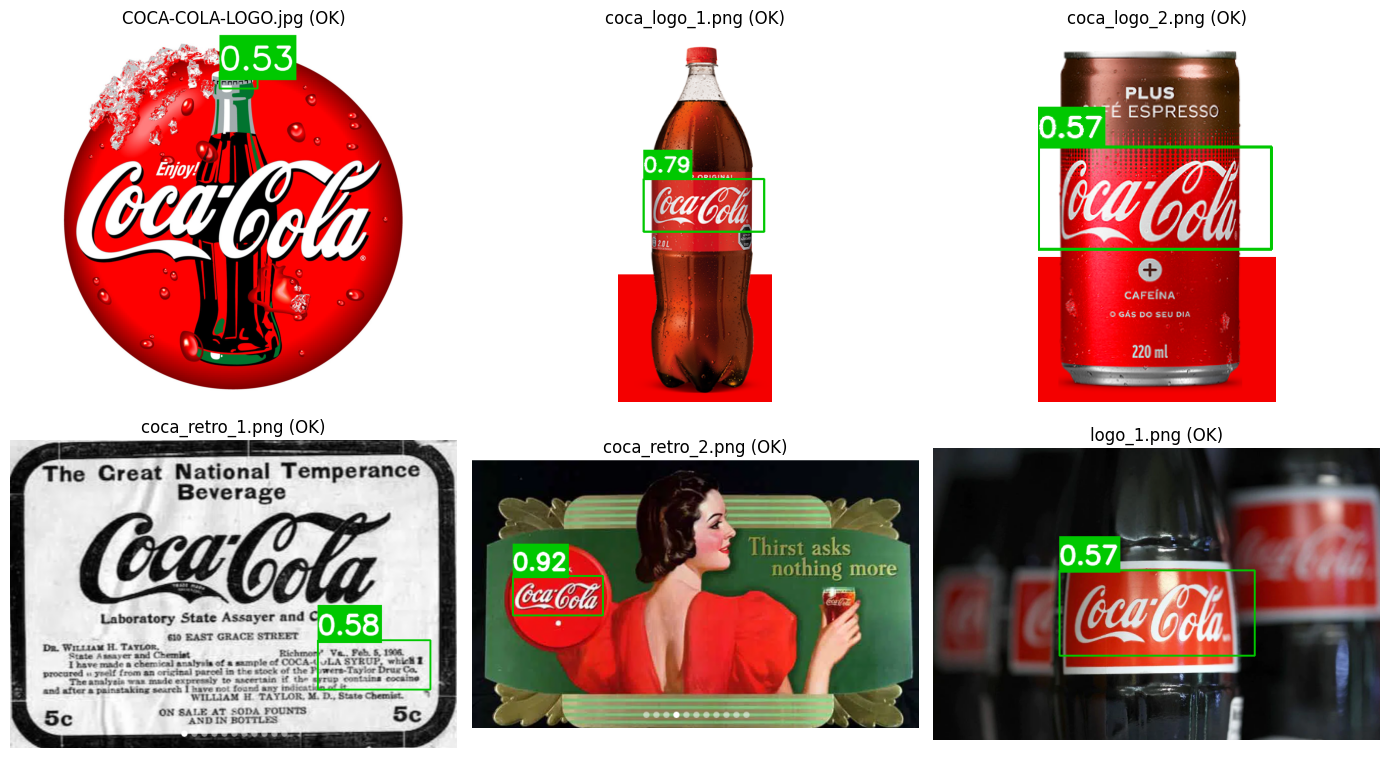

In [21]:
# Parámetros del experimento 1.2 (bordes)
UMBRAL_CONFIANZA_BORDES = 0.50
N_ESCALAS_BORDES = 40
MIN_LADO_BORDES = 55
CANNY_T1, CANNY_T2 = 50, 150
CANNY_BLUR = 5
CANNY_DILATE = 2


def mapa_bordes_suaves(gris, t1=CANNY_T1, t2=CANNY_T2, blur=CANNY_BLUR, dilate=CANNY_DILATE):
    """Canny + dilatación + blur para obtener bordes correlacionables."""
    suavizada = cv2.GaussianBlur(gris, (blur, blur), 0)
    bordes = cv2.Canny(suavizada, t1, t2)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate * 2 + 1, dilate * 2 + 1))
    bordes = cv2.dilate(bordes, kernel)
    return cv2.GaussianBlur(bordes, (5, 5), 0)


def detectar_logo_bordes(
    imagen_bgr,
    template_bgr,
    metrica=METRICA_TM,
    n_escalas=N_ESCALAS_BORDES,
    min_lado=MIN_LADO_BORDES,
):
    """Template matching multi-escala sobre mapas de bordes suaves."""
    imagen_gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
    template_gris = cv2.cvtColor(template_bgr, cv2.COLOR_BGR2GRAY)
    imagen_bordes = mapa_bordes_suaves(imagen_gris)

    alto_t, ancho_t = template_gris.shape[:2]
    mejor = None

    for escala in escalas_validas(
        *imagen_bordes.shape[:2], alto_t, ancho_t, n_escalas, min_lado
    ):
        ancho = int(round(ancho_t * escala))
        alto = int(round(alto_t * escala))
        if ancho < 25 or alto < 15:
            continue
        if ancho >= imagen_bordes.shape[1] or alto >= imagen_bordes.shape[0]:
            continue

        interpolacion = cv2.INTER_AREA if escala < 1 else cv2.INTER_CUBIC
        # Redimensionar en gris y recién ahí calcular bordes (más estable)
        tmpl_gris = cv2.resize(template_gris, (ancho, alto), interpolation=interpolacion)
        tmpl_bordes = mapa_bordes_suaves(tmpl_gris)
        if tmpl_bordes.sum() < 40:
            continue

        mapa = cv2.matchTemplate(imagen_bordes, tmpl_bordes, metrica)
        _, max_val, _, max_loc = cv2.minMaxLoc(mapa)
        candidato = {
            "score": float(max_val),
            "x": int(max_loc[0]),
            "y": int(max_loc[1]),
            "w": ancho,
            "h": alto,
            "escala": float(escala),
            "invertido": False,  # en bordes no aplica polaridad de intensidad
        }
        if mejor is None or candidato["score"] > mejor["score"]:
            mejor = candidato

    return mejor


detecciones_item1_bordes = {}
for nombre, img in imagenes.items():
    detecciones_item1_bordes[nombre] = detectar_logo_bordes(img, template)

print(f"Umbral de confianza (bordes): {UMBRAL_CONFIANZA_BORDES}")
print(f"{'imagen':30} {'score':>7} {'escala':>7} {'estado'}")
print("-" * 60)
for nombre, det in detecciones_item1_bordes.items():
    ok = det["score"] >= UMBRAL_CONFIANZA_BORDES
    estado = "aceptada" if ok else "rechazada"
    print(f"{nombre:30} {det['score']:7.3f} {det['escala']:7.3f} {estado}")

n = len(imagenes)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (nombre, img) in zip(axes, imagenes.items()):
    vis, aceptada = dibujar_deteccion(
        img, detecciones_item1_bordes[nombre], UMBRAL_CONFIANZA_BORDES, nombre
    )
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{nombre} ({'OK' if aceptada else 'bajo umbral'})")
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


#### 4.4 Resultados template matching sobre bordes (Canny)

El uso de bordes mejora justo lo que fallaba en grises: en la botella, la lata y *logo_1* la caja vuelve a caer sobre el script. En *coca_retro_2* el resultado se mantiene bien.

El costo aparece en escenas con muchos contornos: en *COCA-COLA-LOGO* y *coca_retro_1* el score pasa el umbral y la caja se pinta en verde, pero apunta a un detalle o a un bloque de texto, no al logo. Otra vez, confianza alta no alcanza si la ubicación es incorrecta.

En resumen, los bordes no reemplazan al gris: intercambian aciertos. Parece interesante combinar ambos enfoques.


#### 4.5 Híbrido gris + bordes

Los experimentos anteriores se complementan: el gris acierta en avisos/logo grande y falla en botella/lata; los bordes hacen lo inverso. Por eso se ejecutan **ambas** detecciones y se elige una sola con una **regla fija**, igual para todas las imágenes.

La regla, en orden, es:

1. **Consenso:** si las dos cajas se parecen (se solapan bastante, IoU alto) y ambas tienen buen score, se queda la de mayor confianza.
2. **Bordes muy confiables:** si el score de bordes es alto y la caja no es ni minúscula ni enorme respecto de la imagen, se eligen bordes.
3. **Gris muy confiable:** si el score en grises es alto y el tamaño de caja es razonable, se elige gris.
4. **Bordes cuando el gris es débil:** si bordes supera su umbral, la caja tiene buen tamaño y el gris no llega al suyo, se eligen bordes.
5. **Gris aceptable:** si el gris pasa umbral y el área es razonable, se elige gris.
6. Si nada de lo anterior cierra, se toma la mejor opción entre las cajas de tamaño razonable; como último recurso, la de mayor score.

Así se aprovecha lo mejor de cada método y se filtran cajas engañosas (por ejemplo, muy chicas) usando template matching, multi-escala, Canny e IoU.


imagen                         metodo    score regla              iou estado
------------------------------------------------------------------------------
COCA-COLA-LOGO.jpg             gris      0.612 gris_alto         0.00 aceptada
coca_logo_1.png                bordes    0.788 bordes_alto       0.06 aceptada
coca_logo_2.png                bordes    0.572 bordes_medio      0.00 aceptada
coca_retro_1.png               gris      0.630 gris_alto         0.00 aceptada
coca_retro_2.png               bordes    0.923 consenso_iou      0.91 aceptada
logo_1.png                     bordes    0.570 mejor_area_ok     0.00 aceptada


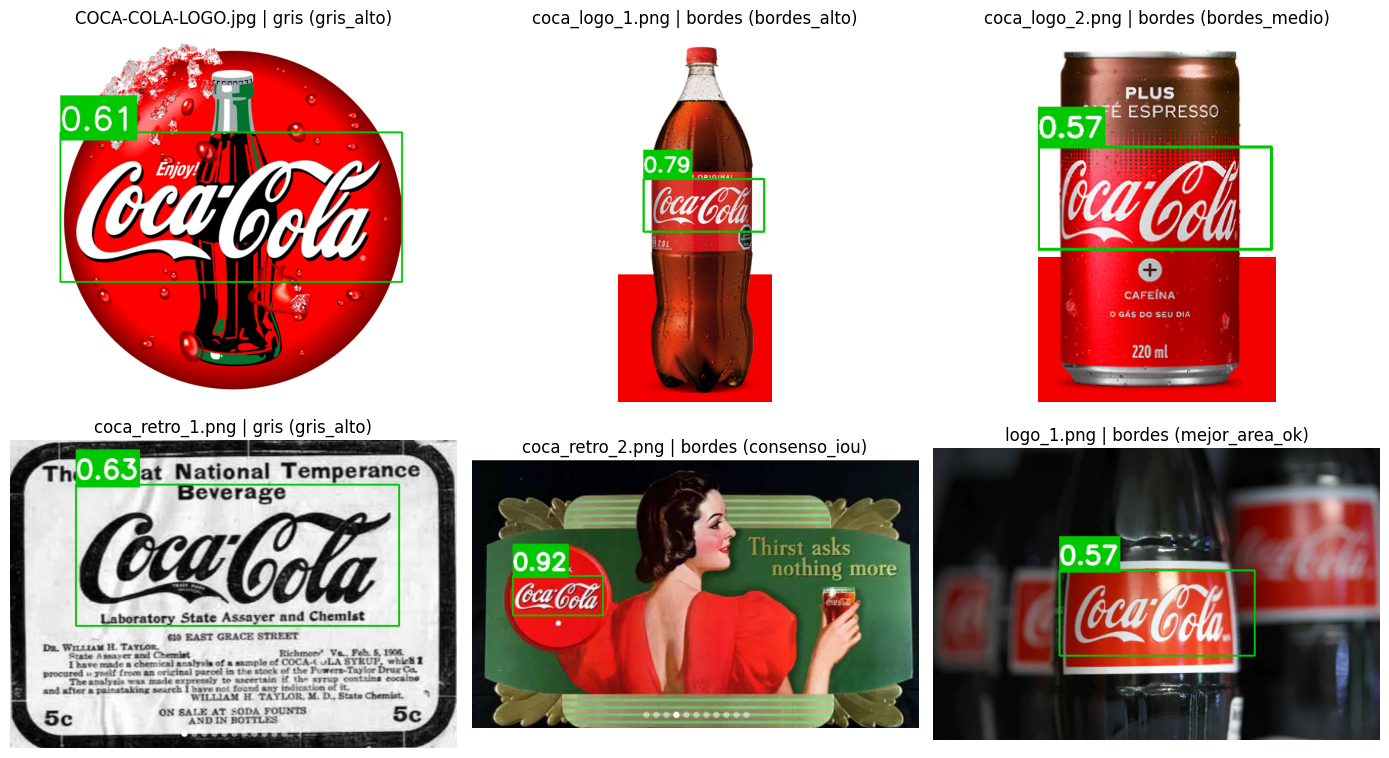

In [22]:
# Parámetros del híbrido 1.3
UMBRAL_GRIS = 0.45
UMBRAL_BORDES = 0.50
IOU_CONSENSO = 0.25
SCORE_BORDES_ALTO = 0.70
SCORE_GRIS_ALTO = 0.55
AREA_REL_MIN = 0.015
AREA_REL_MAX = 0.40


def iou_cajas(a, b):
    """IoU entre dos detecciones con claves x, y, w, h."""
    ax2, ay2 = a["x"] + a["w"], a["y"] + a["h"]
    bx2, by2 = b["x"] + b["w"], b["y"] + b["h"]
    ix1, iy1 = max(a["x"], b["x"]), max(a["y"], b["y"])
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    union = a["w"] * a["h"] + b["w"] * b["h"] - inter
    return inter / union


def area_relativa(det, imagen_bgr):
    return (det["w"] * det["h"]) / (imagen_bgr.shape[0] * imagen_bgr.shape[1])


def area_razonable(det, imagen_bgr, amin=AREA_REL_MIN, amax=AREA_REL_MAX):
    ar = area_relativa(det, imagen_bgr)
    return amin <= ar <= amax


def seleccionar_deteccion_hibrida(det_gris, det_bordes, imagen_bgr):
    """
    Elige entre detección en gris y en bordes.

    Orden: consenso IoU → bordes muy confiables → gris muy confiable →
    bordes si el gris es débil → gris aceptable → mejor con área ok → fallback por score.
    """
    g = {**det_gris, "metodo": "gris"}
    b = {**det_bordes, "metodo": "bordes"}

    g_ok = g["score"] >= UMBRAL_GRIS
    b_ok = b["score"] >= UMBRAL_BORDES

    # 1) Si ambas son aceptables y se solapan, nos quedamos con la de mayor score
    if g_ok and b_ok and iou_cajas(g, b) >= IOU_CONSENSO:
        elegida = g if g["score"] >= b["score"] else b
        return {**elegida, "regla": "consenso_iou", "iou": iou_cajas(g, b)}

    # 2) Bordes con score alto y caja de tamaño razonable
    if b["score"] >= SCORE_BORDES_ALTO and area_razonable(b, imagen_bgr):
        return {**b, "regla": "bordes_alto", "iou": iou_cajas(g, b)}

    # 3) Gris con score alto y caja razonable (retros / logo grande)
    if g["score"] >= SCORE_GRIS_ALTO and area_razonable(g, imagen_bgr):
        return {**g, "regla": "gris_alto", "iou": iou_cajas(g, b)}

    # 4) Bordes medios cuando el gris no alcanza umbral
    if b_ok and area_razonable(b, imagen_bgr) and g["score"] < UMBRAL_GRIS:
        return {**b, "regla": "bordes_medio", "iou": iou_cajas(g, b)}

    # 5) Gris aceptable con área razonable
    if g_ok and area_razonable(g, imagen_bgr):
        return {**g, "regla": "gris_medio", "iou": iou_cajas(g, b)}

    # 6) Entre candidatos con área ok, el de mayor score
    candidatos = []
    if area_razonable(b, imagen_bgr):
        candidatos.append(b)
    if area_razonable(g, imagen_bgr):
        candidatos.append(g)
    if candidatos:
        elegida = max(candidatos, key=lambda d: d["score"])
        return {**elegida, "regla": "mejor_area_ok", "iou": iou_cajas(g, b)}

    elegida = g if g["score"] >= b["score"] else b
    return {**elegida, "regla": "fallback_score", "iou": iou_cajas(g, b)}


def umbral_de_metodo(det):
    return UMBRAL_BORDES if det["metodo"] == "bordes" else UMBRAL_GRIS


detecciones_item1_hibrido = {}
for nombre, img in imagenes.items():
    det_g = detectar_logo_multiescala(img, template)
    det_b = detectar_logo_bordes(img, template)
    detecciones_item1_hibrido[nombre] = seleccionar_deteccion_hibrida(det_g, det_b, img)

print(f"{'imagen':30} {'metodo':7} {'score':>7} {'regla':16} {'iou':>5} {'estado'}")
print("-" * 78)
for nombre, det in detecciones_item1_hibrido.items():
    umbral = umbral_de_metodo(det)
    ok = det["score"] >= umbral
    print(
        f"{nombre:30} {det['metodo']:7} {det['score']:7.3f} {det['regla']:16} "
        f"{det['iou']:5.2f} {'aceptada' if ok else 'rechazada'}"
    )

n = len(imagenes)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (nombre, img) in zip(axes, imagenes.items()):
    det = detecciones_item1_hibrido[nombre]
    vis, aceptada = dibujar_deteccion(img, det, umbral_de_metodo(det), nombre)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{nombre} | {det['metodo']} ({det['regla']})")
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


#### 4.6 Resultados híbrido

Al combinar gris y bordes con una regla fija (scores, IoU y tamaño de caja), cada escena queda con el método que mejor le funciona: gris para el logo grande y el aviso *coca_retro_1*; bordes para botella, lata, *logo_1* y *coca_retro_2*.

En esta corrida, las seis cajas caen sobre el logo. El híbrido cierra el intercambio de errores entre 1.1 y 1.2 sin seleccionar a mano el archivo, y deja el ítem 1 en un estado usable para pasar a múltiples detecciones.


#### 4.7 Resumen y conclusiones

Se partió de **template matching multi-escala en grises**. Ese enfoque localizó bien logos planos (avisos y el logo grande), pero falló en botella/lata y aceptó un falso positivo engañoso en *logo_1*: el score pasaba el umbral aunque la caja no estaba sobre el patrón.

Para corregir eso se pasó a **matching sobre bordes (Canny)**. Ahí mejoraron los productos reales y se corrigió *logo_1*, pero aparecieron errores nuevos en escenas con muchos contornos (*COCA-COLA-LOGO* y *coca_retro_1*), otra vez con cajas “verdes” mal ubicadas.

Como cada método resolvía lo que el otro no, el paso final fue un **híbrido**: se calculan ambas detecciones y se elige una con una regla fija (confianza, solapamiento IoU y tamaño de caja). Con eso se conserva lo mejor de cada experimento y se logra una identificación correcta del logo en todas las escenas. 

### 5. Resolución punto 2 (Completar)

### 6. Resolución punto 3 (Completar)

### 7. Conclusiones (Completar al final)